<a href="https://colab.research.google.com/github/CBravoR/AdvancedAnalyticsLabs/blob/master/notebooks/python/Lab_Fairness_Credit_Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fairness in Credit Scoring

In this lab we audit a credit scoring model for fairness with respect to a protected attribute. We follow the lecture: we **measure** the three fairness criteria (independence, separation, sufficiency), we **test** whether the gaps we see are larger than sampling noise, we **treat** the model at post-processing with group-specific cutoffs, and we close by showing how easy it is to make a model *look* fair (D-hacking).

The lab has two parts.

- **Part A** measures fairness with the [`fairlearn`](https://fairlearn.org/) library. It is adapted, with small changes, from the Chapter 8 lab *Building Ethical and Transparent AI Models: Fairness and Explainability*, written by María Óskarsdóttir for Bravo, C., Maldonado, S. and Óskarsdóttir, M. (2025), *Deep Learning in Banking: Integrating Artificial Intelligence for Next-Generation Financial Services*, Wiley. The book's labs are at [bankingbook.ml](https://bankingbook.ml). The explainability half of that lab, which explains a transformer with SHAP, is not part of this lecture and is left out.
- **Part B** adds what the lecture covers: confounding through a legitimate variable, statistical tests with traffic lights, post-processing with `ThresholdOptimizer`, the impossibility theorem seen in data, and a D-hacking demonstration.

Two treatment stages from the lecture are **not** in this lab: pre-processing (reweighing, disparate-impact removal) and in-processing (constrained estimation) need the model's input variables, and the dataset we use here contains only the model's outputs. Keep that in mind when you read the results: everything below is what a **validator** can do with the scores alone.

In [1]:
!pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 1.3 MB/s eta 0:00:00a 0:00:01


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import accuracy_score, precision_score, roc_curve, auc, brier_score_loss, balanced_accuracy_score
from sklearn.calibration import calibration_curve

import fairlearn
from fairlearn.metrics import (
    MetricFrame, count, selection_rate,
    true_positive_rate, true_negative_rate, false_positive_rate, false_negative_rate,
    demographic_parity_difference, demographic_parity_ratio,
    equalized_odds_difference, equalized_odds_ratio,
    equal_opportunity_difference, equal_opportunity_ratio,
)
print('fairlearn', fairlearn.__version__)

fairlearn 0.14.0


## Part A: Measuring fairness

### The data

We assume the model is already trained, with variables such as income, credit score and interest rate, and that it never saw the protected attribute. The target has two values: 0 for non-default and 1 for default. The question is whether the model discriminates by a sensitive attribute that is, in this case, a **proxy for race**: it was built from the first three digits of the postcode and census information on the ethnic majority of the area. As the lecture says, this is exactly how a bank that does not collect race has to audit for it, and it is exactly the kind of proxy that carries its own error.

The file has five columns:

- `true_label`: whether the customer defaulted (1) or not (0).
- `predicted_label`: the model's decision. Note that a 1 means *predicted default*, so a high selection rate is bad news for a group.
- `predicted_probability`: the model's score, between 0 and 1.
- `sensitive_attribute`: the proxy for race, with four levels `a`, `b`, `c`, `d`.
- `credit_score`: the borrower's bureau score. We use it in Part B.

The dataset was created for the book as an illustration of the techniques. It is not a representative sample of any population, and nothing below is a finding about any group of people.

In [3]:
!gdown "https://drive.google.com/uc?id=1XWF9WLIQbAisVTX6yiHFxJ4vK0gKPx1q"

Downloading...
From: https://drive.google.com/uc?id=1XWF9WLIQbAisVTX6yiHFxJ4vK0gKPx1q
To: /content/FairnessDataFrame.csv
100% 206k/206k [00:00<00:00, 105MB/s]


In [4]:
fairness_df = pd.read_csv('FairnessDataFrame.csv')
A = fairness_df['sensitive_attribute']
y = fairness_df['true_label']
yhat = fairness_df['predicted_label']
p = fairness_df['predicted_probability']
print(fairness_df.shape)
fairness_df.head()

(6983, 5)


,true_label,predicted_label,predicted_probability,credit_score,sensitive_attribute
0,0,0,0.253559,740,c
1,0,0,0.042416,797,b
2,0,0,0.402585,761,c
3,1,0,0.496127,716,b
4,0,0,0.344999,695,c


We start with the group sizes and the default rate per group. Group `b` is the largest and has the highest default rate; group `c` has the lowest. The base rates differ across groups, and that is the condition under which the three fairness criteria cannot all hold. Keep this table in mind for everything that follows.

,n,default_rate,predicted_default_rate,mean_score,mean_credit_score
sensitive_attribute,,,,,
a,1272,0.026,0.291,0.358,746.490
b,2295,0.030,0.290,0.354,745.029
c,2131,0.020,0.233,0.325,750.220
d,1285,0.026,0.268,0.353,745.073


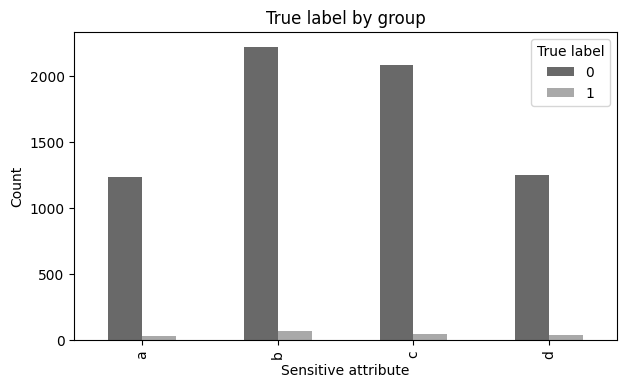

In [5]:
profile = fairness_df.groupby('sensitive_attribute').agg(
    n=('true_label', 'size'),
    default_rate=('true_label', 'mean'),
    predicted_default_rate=('predicted_label', 'mean'),
    mean_score=('predicted_probability', 'mean'),
    mean_credit_score=('credit_score', 'mean'),
).round(3)
display(profile)

counts = fairness_df.groupby(['sensitive_attribute', 'true_label']).size().unstack(fill_value=0)
counts.plot(kind='bar', color=['dimgray', 'darkgrey'], figsize=(7, 4))
plt.xlabel('Sensitive attribute'); plt.ylabel('Count'); plt.title('True label by group'); plt.legend(title='True label')
plt.show()

### Metrics by group

`fairlearn` organises everything around the `MetricFrame`: you give it a dictionary of metrics, the true labels, the predictions and the sensitive feature, and it computes every metric overall and per group. We include the metrics that map to the three criteria of the lecture:

- **Selection rate** (share predicted as default) is what independence compares.
- **True positive rate** and **false positive rate** are what separation compares.
- **Precision** (positive predictive value) is one half of sufficiency; we add calibration below.

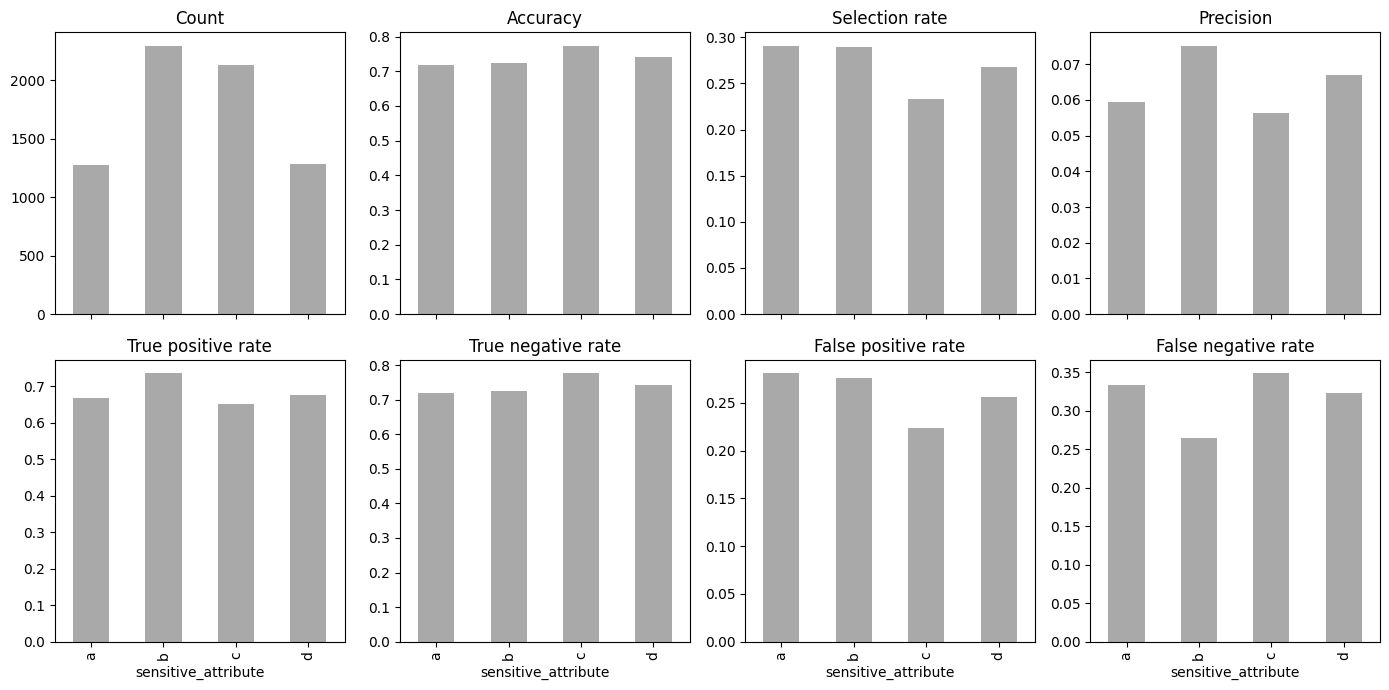

In [6]:
metrics = {
    'Count': count,
    'Accuracy': accuracy_score,
    'Selection rate': selection_rate,
    'Precision': precision_score,
    'True positive rate': true_positive_rate,
    'True negative rate': true_negative_rate,
    'False positive rate': false_positive_rate,
    'False negative rate': false_negative_rate,
}
metric_frame = MetricFrame(metrics=metrics, y_true=y, y_pred=yhat, sensitive_features=A)
metric_frame.by_group.plot.bar(subplots=True, layout=[2, 4], legend=False, figsize=[14, 7], color='darkgrey')
plt.tight_layout(); plt.show()

Read the panels with the criteria in mind. Group `c` has the lowest selection rate and the lowest false positive rate: the model is the least likely to call its members defaulters, and when they are good payers it is the least likely to be wrong about them. Groups `a` and `b` sit at the other end. The true positive rate is highest for `b`. Accuracy is similar everywhere, which is the usual story: a model can be equally *accurate* across groups and still make different *kinds* of errors for each.

The summary below gives, for every metric, the largest difference between two groups, the smallest ratio, and the group minimum and maximum.

In [7]:
summary = pd.DataFrame({
    'difference': metric_frame.difference(),
    'ratio': metric_frame.ratio(),
    'group_min': metric_frame.group_min(),
    'group_max': metric_frame.group_max(),
}).T
summary

,Count,Accuracy,Selection rate,Precision,True positive rate,True negative rate,False positive rate,False negative rate
difference,1023.000000,0.055579,0.058126,0.018736,0.084131,0.056734,0.056734,0.084131
ratio,0.554248,0.928132,0.800172,0.750806,0.885581,0.926877,0.798008,0.758824
group_min,1272.000000,0.717767,0.232755,0.056452,0.651163,0.719128,0.224138,0.264706
group_max,2295.000000,0.773346,0.290881,0.075188,0.735294,0.775862,0.280872,0.348837


### Independence

Independence asks that the decision does not depend on the group: equal selection rates. `fairlearn` reports it as **demographic parity**, as a difference (max minus min selection rate across groups) and as a ratio (min over max).

The ratio is the statistic behind the US **four-fifths rule** from the lecture: a selection-rate ratio below 0.8 flags adverse impact. Remember what "selection" means here: being predicted as a defaulter. A ratio of 0.8 means the most-flagged group is flagged 25% more often than the least-flagged one.

In [8]:
DPD = demographic_parity_difference(y, yhat, sensitive_features=A, method='between_groups')
DPR = demographic_parity_ratio(y, yhat, sensitive_features=A, method='between_groups')
print(f'Demographic parity difference: {DPD:.3f}')
print(f'Demographic parity ratio:      {DPR:.3f}   (four-fifths rule flags values below 0.80)')

Demographic parity difference: 0.058
Demographic parity ratio:      0.800   (four-fifths rule flags values below 0.80)


The difference is positive and the ratio is below one, so the decision does depend on the group. Whether this is *evidence* of unfairness is the question Part B answers; for now it is a measurement.

### Separation

Separation asks that the error rates be equal given the true outcome. With a binary decision this is **equalised odds** (Hardt, Price and Srebro, 2016): equal true positive rates and equal false positive rates. `fairlearn` reports the larger of the two gaps. **Equal opportunity** relaxes it to the true positive rate only.

In [9]:
EOD = equalized_odds_difference(y, yhat, sensitive_features=A, method='between_groups')
EOR = equalized_odds_ratio(y, yhat, sensitive_features=A, method='between_groups')
EOpD = equal_opportunity_difference(y, yhat, sensitive_features=A, method='between_groups')
EOpR = equal_opportunity_ratio(y, yhat, sensitive_features=A, method='between_groups')
print(f'Equalized odds difference:    {EOD:.3f}')
print(f'Equalized odds ratio:         {EOR:.3f}')
print(f'Equal opportunity difference: {EOpD:.3f}')
print(f'Equal opportunity ratio:      {EOpR:.3f}')

Equalized odds difference:    0.084
Equalized odds ratio:         0.798
Equal opportunity difference: 0.084
Equal opportunity ratio:      0.886


#### Separation on the ROC curve

The lecture showed separation as a picture: one ROC curve per group, and the region under **all** curves as the set of (false positive rate, true positive rate) pairs that every group can reach. Any point in the shaded region can be attained by every group with its own cutoff, sometimes by randomising between two cutoffs. A single cutoff for everybody puts each group at a different point of its own curve, which is why separation fails.

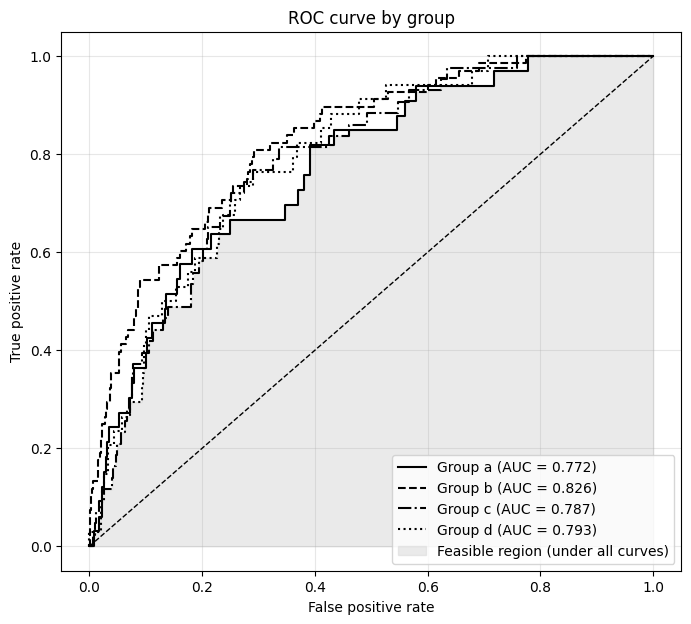

In [10]:
groups = sorted(A.unique())
styles = ['-', '--', '-.', ':']
fig, ax = plt.subplots(figsize=(8, 7))
roc_curves = []
for i, g in enumerate(groups):
    idx = A == g
    fpr, tpr, _ = roc_curve(y[idx], p[idx])
    roc_curves.append((fpr, tpr))
    ax.plot(fpr, tpr, 'k', linestyle=styles[i], label=f'Group {g} (AUC = {auc(fpr, tpr):.3f})')
common_fpr = np.linspace(0, 1, 500)
min_tpr = np.min([np.interp(common_fpr, fpr, tpr) for fpr, tpr in roc_curves], axis=0)
ax.fill_between(common_fpr, min_tpr, color='gainsboro', alpha=0.6, label='Feasible region (under all curves)')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate'); ax.set_title('ROC curve by group')
ax.legend(loc='lower right'); ax.grid(alpha=.3)
plt.show()

Group `a` has the weakest curve and drags the feasible region down in the middle of the range; group `b` is the strongest at low false positive rates. The model discriminates *better* for some groups than for others. This is the noise argument of Blattner and Nelson (2021) from the lecture: with the same model, thinner or noisier files produce a flatter ROC curve, and the group pays for it with more errors.

### Sufficiency

Sufficiency asks that, given the score, the outcome does not depend on the group. For a binary decision the usual check is **predictive rate parity**: equal precision across groups. The lecture defined sufficiency through **calibration by group**, so we add that check: within each group, does a predicted probability of *r* correspond to a default rate of *r*?

Precision by group:


sensitive_attribute,a,b,c,d
Precision,0.059,0.075,0.056,0.067


Largest precision gap between groups: 0.019


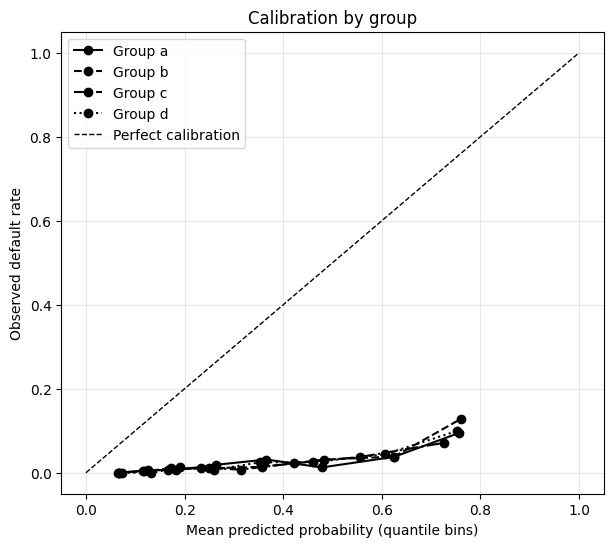

,mean score,default rate,Brier,ECE
group,,,,
a,0.358,0.026,0.178,0.332
b,0.354,0.030,0.173,0.324
c,0.325,0.020,0.151,0.305
d,0.353,0.026,0.171,0.327


In [11]:
print('Precision by group:')
display(metric_frame.by_group['Precision'].round(3).to_frame().T)
print(f"Largest precision gap between groups: {metric_frame.difference()['Precision']:.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
cal = []
for i, g in enumerate(groups):
    idx = A == g
    frac_pos, mean_pred = calibration_curve(y[idx], p[idx], n_bins=8, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', color='k', linestyle=styles[i], label=f'Group {g}')
    # expected calibration error: weighted mean absolute gap between predicted and observed
    bins = pd.qcut(p[idx], 8, duplicates='drop')
    ece = (fairness_df[idx].groupby(bins, observed=True)
           .apply(lambda d: abs(d['predicted_probability'].mean() - d['true_label'].mean()) * len(d) / idx.sum(), include_groups=False).sum())
    cal.append({'group': g, 'mean score': p[idx].mean(), 'default rate': y[idx].mean(),
                'Brier': brier_score_loss(y[idx], p[idx]), 'ECE': ece})
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability (quantile bins)'); ax.set_ylabel('Observed default rate')
ax.set_title('Calibration by group'); ax.legend(); ax.grid(alpha=.3)
plt.show()
pd.DataFrame(cal).set_index('group').round(3)

Two things to see. First, the precision gap across groups is small, so on predictive rate parity the model looks close to sufficient. Second, the calibration plot says something the precision gap hides: the **scores are not probabilities of default**. The mean score is around 0.35 for every group while default rates are around 2 to 3 percent. The model ranks (its AUC is 0.80) but it is not calibrated, for anybody. Calibration by group therefore fails for every group in the same direction.

This matters for the lecture's definition: sufficiency compares groups *given the score*. If the score is far from a probability for everyone, "equal miscalibration" is what sufficiency looks like here. A calibration step (the PD calibration lab) would fix the level; whether it would fix it equally for all groups is exactly what the impossibility theorem says cannot be guaranteed together with separation. We come back to this in Part B.

### Part A summary

The model shows small but consistent group differences: a demographic parity ratio below 0.8 and equalised odds gaps of a few percentage points, with group `c` treated most leniently and group `a` served by the weakest ROC curve. None of the gaps exceeds the 0.10 rule of thumb that practitioners often use. Does that make the model fair? A rule of thumb is not a test. Part B turns each of these numbers into a decision.

## Part B: From measuring to deciding

### B1. Confounding: the model never saw the group

The model was trained without the sensitive attribute, and it still produces different selection rates by group. The lecture's explanation is **confounding**: a legitimate variable carries the group information. The one legitimate variable we have is the credit score, so we check whether it explains the gap.

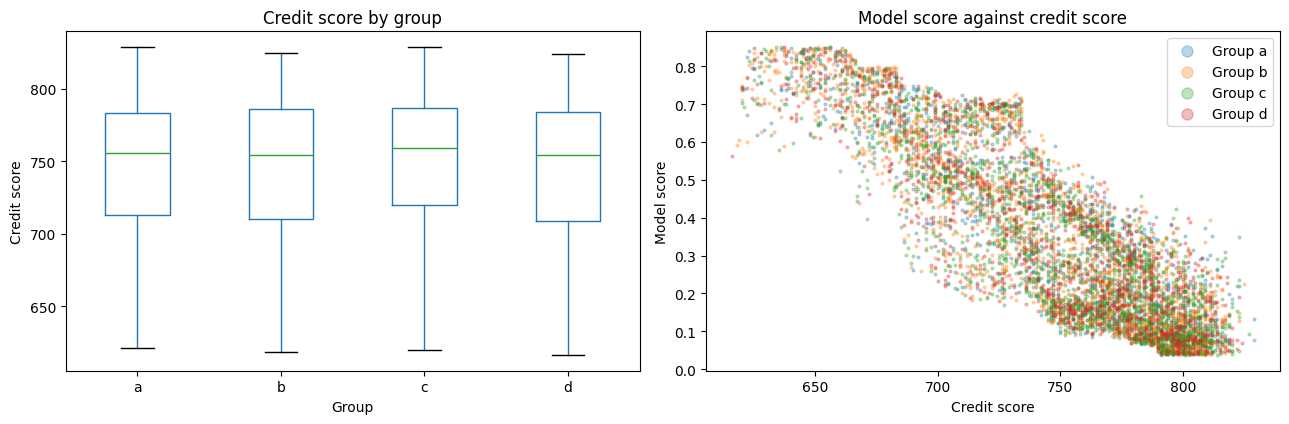

Correlation between credit score and model score, by group:
sensitive_attribute
a   -0.874
b   -0.880
c   -0.864
d   -0.866
dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fairness_df.boxplot(column='credit_score', by='sensitive_attribute', ax=axes[0], grid=False)
axes[0].set_title('Credit score by group'); axes[0].set_xlabel('Group'); axes[0].set_ylabel('Credit score')
for i, g in enumerate(groups):
    idx = A == g
    axes[1].scatter(fairness_df.loc[idx, 'credit_score'], p[idx], s=4, alpha=.3, label=f'Group {g}')
axes[1].set_xlabel('Credit score'); axes[1].set_ylabel('Model score'); axes[1].set_title('Model score against credit score')
axes[1].legend(markerscale=4)
plt.suptitle(''); plt.tight_layout(); plt.show()

print('Correlation between credit score and model score, by group:')
print(fairness_df.groupby('sensitive_attribute').apply(lambda d: d['credit_score'].corr(d['predicted_probability']), include_groups=False).round(3))

Now the regression that the lecture describes as the confounding check. We regress the model's decision on the credit score and on group indicators. If the group indicators are zero **given** the credit score, the credit score explains the whole gap: the model is "unaware" and the disparity is a difference in the legitimate variable. If the group coefficients survive, something else in the model is affecting the group.

We use a logistic regression from `statsmodels` so that we get standard errors.

In [13]:
import statsmodels.formula.api as smf

m0 = smf.logit('predicted_label ~ C(sensitive_attribute, Treatment("c"))', data=fairness_df).fit(disp=0)
m1 = smf.logit('predicted_label ~ credit_score + C(sensitive_attribute, Treatment("c"))', data=fairness_df).fit(disp=0)

def tidy(m, label):
    out = pd.DataFrame({'coef': m.params, 'se': m.bse, 'p-value': m.pvalues}).round(3)
    out.columns = pd.MultiIndex.from_product([[label], out.columns])
    return out
tbl = pd.concat([tidy(m0, 'Group only'), tidy(m1, 'Group + credit score')], axis=1)
tbl.index = [i.replace('C(sensitive_attribute, Treatment("c"))', 'group ') for i in tbl.index]
tbl

Group only                Group + credit score               
                   coef     se p-value                 coef     se p-value
Intercept        -1.193  0.051   0.000               54.372  1.458   0.000
group [T.a]       0.302  0.080   0.000                0.499  0.137   0.000
group [T.b]       0.296  0.069   0.000                0.243  0.117   0.039
group [T.d]       0.187  0.081   0.022               -0.062  0.138   0.651
credit_score        NaN    NaN     NaN               -0.076  0.002   0.000

Read the two columns of coefficients against each other, with group `c` (the leniently treated one) as the reference. In the first model the group indicators pick up the raw selection-rate gap: all three are positive and significant. In the second, the credit score enters with a large negative coefficient, as it should, and the picture splits. The gap for group `d` disappears: given the credit score, `d` is treated like `c`, so for that group the credit score *is* the confounder. The gaps for groups `a` and `b` survive, and the one for `a` grows. For those two groups the model has found the group through variables we cannot see here, and the credit score is not the explanation.

This is the pattern the lecture warned about: the same model can be "explained by a legitimate variable" for one group and not for another. Note also what "unawareness" bought us: **nothing**. The attribute is not in the model and the gap is still there. The lecture's evidence (Fuster et al., 2022; Gillis and Spiess, 2019; Kelley et al., 2022) says this is the normal case. **Fairness through unawareness is a myth.**

### B2. Testing fairness

A demographic parity difference of a few points is a sample statistic. The validator's question, as in the calibration lecture, is **whether the gap is larger than sampling error**. Hurlin, Pérignon and Saurin (2026) formalise this: the null hypothesis is that the fairness metric takes the same value in the protected group and in the rest of the population, and the test is a Wald test on the difference. We do three versions, from simplest to closest to the paper.

**1. Bootstrap confidence intervals.** Resample the rows with replacement and recompute the between-groups gaps. This gives a confidence band around the measured value. One caution: the between-groups gap is a maximum minus a minimum, and extreme statistics are biased upward under resampling, so read the interval, not only the point estimate.

In [14]:
rng = np.random.default_rng(20260909)
B = 500
boot = np.zeros((B, 2))
n = len(fairness_df)
for b in range(B):
    idx = rng.integers(0, n, n)
    boot[b, 0] = demographic_parity_difference(y.values[idx], yhat.values[idx], sensitive_features=A.values[idx], method='between_groups')
    boot[b, 1] = equalized_odds_difference(y.values[idx], yhat.values[idx], sensitive_features=A.values[idx], method='between_groups')
ci = np.percentile(boot, [2.5, 97.5], axis=0)
print(f'Demographic parity difference: {DPD:.3f}   95% bootstrap CI [{ci[0,0]:.3f}, {ci[1,0]:.3f}]')
print(f'Equalized odds difference:     {EOD:.3f}   95% bootstrap CI [{ci[0,1]:.3f}, {ci[1,1]:.3f}]')

Demographic parity difference: 0.058   95% bootstrap CI [0.037, 0.090]
Equalized odds difference:     0.084   95% bootstrap CI [0.068, 0.325]


**2. Permutation test.** Under the null hypothesis that the decision does not depend on the group, shuffling the group labels changes nothing. We shuffle them many times, recompute the gap, and see how often a gap as large as the observed one appears by chance. The share is the p-value. This test needs no distributional assumption and it handles the max-minus-min statistic correctly, because it simulates the whole statistic under the null.

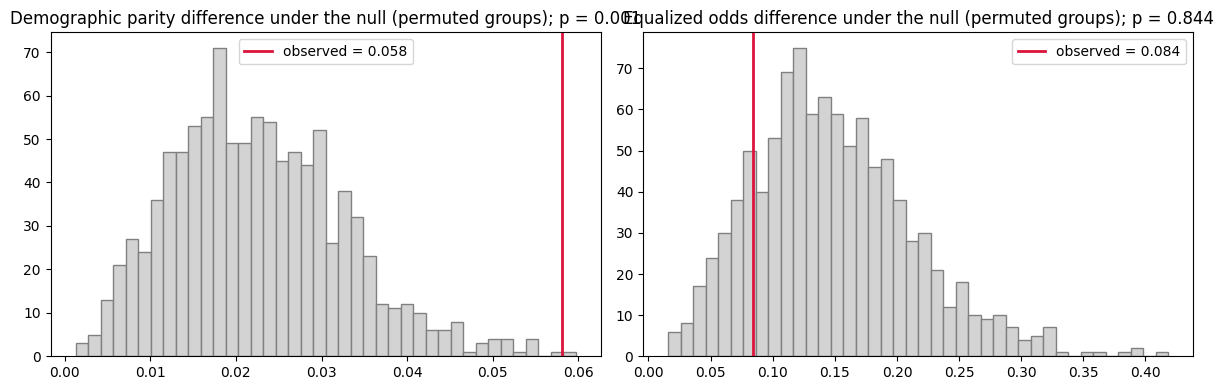

Permutation p-value, demographic parity difference: 0.001
Permutation p-value, equalized odds difference:     0.844


In [15]:
P = 1000
perm = np.zeros((P, 2))
A_arr = A.values.copy()

# Calculate the permutation distribution of the fairness metrics 
for k in range(P):
    A_perm = rng.permutation(A_arr)
    perm[k, 0] = demographic_parity_difference(y, yhat, sensitive_features=A_perm, method='between_groups')
    perm[k, 1] = equalized_odds_difference(y, yhat, sensitive_features=A_perm, method='between_groups')
p_dpd = (perm[:, 0] >= DPD).mean()
p_eod = (perm[:, 1] >= EOD).mean()

# Plot the permutation distributions and observed values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, k, obs, name, pv in zip(axes, [0, 1], [DPD, EOD], ['Demographic parity difference', 'Equalized odds difference'], [p_dpd, p_eod]):
    ax.hist(perm[:, k], bins=40, color='lightgrey', edgecolor='grey')
    ax.axvline(obs, color='crimson', lw=2, label=f'observed = {obs:.3f}')
    ax.set_title(f'{name} under the null (permuted groups); p = {pv:.3f}')
    ax.legend()
plt.tight_layout(); plt.show()
print(f'Permutation p-value, demographic parity difference: {p_dpd:.3f}')
print(f'Permutation p-value, equalized odds difference:     {p_eod:.3f}')

The two gaps now tell different stories. The demographic parity gap of 0.058 is far in the tail of its null distribution: a gap this large almost never appears when the groups are shuffled, so **the dependence of the decision on the group is real**. The equalised odds gap of 0.084 is *not* unusual under the null: shuffled groups produce gaps this large most of the time. The reason is in the bootstrap interval above, which is wide on the right. The equalised odds gap is driven by the true positive rate. Each group's true positive rate is estimated on 25 to 70 defaulters. With that little data, a gap of eight points is noise. The measured value looked like the worse of the two but the test says the opposite.

**3. Group-by-group Wald tests, with traffic lights.** The paper tests one protected group against the rest of the population, one metric at a time. For a rate (selection rate, true positive rate, false positive rate) in group *g* against the rest, the difference divided by its binomial standard error is approximately standard normal. We run it for every group and every rate, and colour the result as in the validation lecture: green if the null is not rejected at 5%, yellow if rejected at 5% but not at 1%, red if rejected at 1%.

Look at the sample sizes next to the true positive rate. Defaults are 2 to 3 percent of each group, so a true positive rate is estimated on a few dozen defaulters. That is the "small groups mean low power" caveat from the lecture, in numbers.

In [16]:
from scipy.stats import norm

def rate_test(mask_num, mask_den, group_mask):
    # rate = mean of mask_num within mask_den; compare group vs rest
    g = mask_den & group_mask; r = mask_den & ~group_mask
    n1, n2 = g.sum(), r.sum()
    p1, p2 = mask_num[g].mean(), mask_num[r].mean()
    se = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    z = (p1 - p2) / se
    return p1, p2, n1, z, 2 * (1 - norm.cdf(abs(z)))

def light(pv):
    return 'red' if pv < 0.01 else ('yellow' if pv < 0.05 else 'green')

pos = y.values == 1; neg = ~pos; pred1 = yhat.values == 1
rows = []
for g in groups:
    gm = (A == g).values
    for name, num, den in [('Selection rate', pred1, np.ones(n, bool)),
                           ('True positive rate', pred1, pos),
                           ('False positive rate', pred1, neg)]:
        p1, p2, n1, z, pv = rate_test(num, den, gm)
        rows.append({'group': g, 'metric': name, 'group rate': p1, 'rest rate': p2, 'n in group': int(n1), 'z': z, 'p-value': pv, 'light': light(pv)})
wald = pd.DataFrame(rows)

def colour(v):
    return {'red': 'background-color: #f4a6a6', 'yellow': 'background-color: #f7e59a', 'green': 'background-color: #b7e1a1'}.get(v, '')
wald.style.format({'group rate': '{:.3f}', 'rest rate': '{:.3f}', 'z': '{:.2f}', 'p-value': '{:.3f}'}).map(colour, subset=['light'])

,group,metric,group rate,rest rate,n in group,z,p-value,light
0,a,Selection rate,0.291,0.264,1272,1.95,0.051,green
1,a,True positive rate,0.667,0.697,33,-0.33,0.741,green
2,a,False positive rate,0.281,0.252,1239,2.04,0.041,yellow
3,b,Selection rate,0.290,0.258,2295,2.77,0.006,red
4,b,True positive rate,0.735,0.664,68,1.02,0.306,green
5,b,False positive rate,0.276,0.248,2227,2.43,0.015,yellow
6,c,Selection rate,0.233,0.284,2131,-4.59,0.000,red
7,c,True positive rate,0.651,0.704,43,-0.64,0.525,green
8,c,False positive rate,0.224,0.272,2088,-4.29,0.000,red
9,d,Selection rate,0.268,0.269,1285,-0.07,0.942,green


The three tests tell one story with different resolution. The permutation test asks whether *any* group differs on *any* side of the gap; the Wald table says *which* group and *which* rate. It also adds a nuance the permutation test missed: the false positive rate gaps for groups `b` and `c` are significant, even though the equalised odds gap as a whole was not. Equalised odds reports the *larger* of the two gaps, which here is the true positive rate gap, and that is the noisy one. The false positive rates are estimated on thousands of good payers, so their smaller gap is the one we can actually trust. In a validation report the table is the deliverable: each red cell is a finding with a group, a metric and a p-value attached, and the yellow cells go on a watch list, exactly as in the PD backtesting dashboard.

Hurlin, Pérignon and Saurin go one step further and ask *which input variables* drive the rejected null, by permuting one variable at a time inside the model. We cannot do that here because we do not have the inputs. That step belongs to the model owner, not the validator.

### B3. Post-processing: group-specific cutoffs

We now treat the model without touching it. `fairlearn`'s `ThresholdOptimizer` implements Hardt, Price and Srebro (2016): it searches, for each group, for the cutoff (or the randomised pair of cutoffs) that puts every group at the same point of the ROC plane, and among those points picks the one that maximises an objective. We ask for **equalised odds**, and we optimise **balanced accuracy** rather than accuracy: with 2 to 3 percent defaults, plain accuracy is maximised by predicting that nobody defaults.

`ThresholdOptimizer` expects an estimator. Our "model" is the score column, so we wrap it in a trivial estimator that returns the score as a probability.

The original decision uses a cutoff of about 0.500 on the score for everybody.
Group-specific decision rules found by ThresholdOptimizer:
  group a: {'p_ignore': np.float64(0.0), 'prediction_constant': np.float64(0.391), 'p0': 0.002127413127412951, 'operation0': [>0.6299024724175101], 'p1': 0.9978725868725871, 'operation1': [>0.3931213806086772]}
  group b: {'p_ignore': np.float64(0.12884797709751505), 'prediction_constant': np.float64(0.391), 'p0': 0.18374253731343265, 'operation0': [>0.4867707524420045], 'p1': 0.8162574626865673, 'operation1': [>0.3637423275916164]}
  group c: {'p_ignore': np.float64(0.0566844455985609), 'prediction_constant': np.float64(0.391), 'p0': 0.8192797427652733, 'operation0': [>0.3889767335281992], 'p1': 0.18072025723472673, 'operation1': [>0.18475432745564024]}
  group d: {'p_ignore': np.float64(0.07192582536147941), 'prediction_constant': np.float64(0.391), 'p0': 0.2681812865497076, 'operation0': [>0.4663149913664885], 'p1': 0.7318187134502925, 'operation1

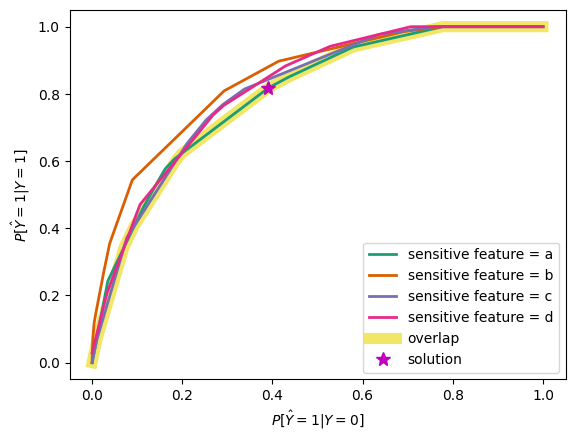

In [17]:
from sklearn.base import BaseEstimator, ClassifierMixin
from fairlearn.postprocessing import ThresholdOptimizer, plot_threshold_optimizer

class ScoreModel(BaseEstimator, ClassifierMixin):
    # A fitted model whose only input is the score it already produced.
    def fit(self, X, y=None):
        self.classes_ = np.array([0, 1]); return self
    def predict_proba(self, X):
        s = np.asarray(X).reshape(-1)
        return np.column_stack([1 - s, s])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

X_score = fairness_df[['predicted_probability']]
implied_threshold = p[yhat == 1].min()
print(f'The original decision uses a cutoff of about {implied_threshold:.3f} on the score for everybody.')

post = ThresholdOptimizer(estimator=ScoreModel().fit(X_score, y),
                          constraints='equalized_odds',
                          objective='balanced_accuracy_score',
                          prefit=True, predict_method='predict_proba')
post.fit(X_score, y, sensitive_features=A)
yhat_post = post.predict(X_score, sensitive_features=A, random_state=20260909)

print('Group-specific decision rules found by ThresholdOptimizer:')
for g, rule in post.interpolated_thresholder_.interpolation_dict.items():
    print(f'  group {g}: {rule}')
plot_threshold_optimizer(post)

The rules read as follows. For each group the decision is a mixture of two cutoffs (`operation0` and `operation1`), applied with probabilities `p0` and `p1`. On top of that, `p_ignore` is the probability of ignoring the score altogether and predicting the constant `prediction_constant`: that is how a group is moved to a point *below* its own ROC curve, so that all groups meet at the same (false positive rate, true positive rate) point. Group `a`, with the weakest curve, needs almost no randomisation; the stronger groups are deliberately degraded towards it. The plot shows the per-group ROC curves and the common point the optimiser selected.

Now the before-and-after comparison, on the metrics that separation cares about.

In [18]:
mf_before = MetricFrame(metrics={'Selection rate': selection_rate, 'True positive rate': true_positive_rate, 'False positive rate': false_positive_rate},
                        y_true=y, y_pred=yhat, sensitive_features=A)
mf_after = MetricFrame(metrics={'Selection rate': selection_rate, 'True positive rate': true_positive_rate, 'False positive rate': false_positive_rate},
                       y_true=y, y_pred=yhat_post, sensitive_features=A)
cmp = pd.concat({'before': mf_before.by_group, 'after': mf_after.by_group}, axis=1).round(3)
display(cmp)

def report(y_true, y_pred):
    return {'Equalized odds difference': equalized_odds_difference(y_true, y_pred, sensitive_features=A, method='between_groups'),
            'Demographic parity difference': demographic_parity_difference(y_true, y_pred, sensitive_features=A, method='between_groups'),
            'Balanced accuracy': balanced_accuracy_score(y_true, y_pred),
            'Overall predicted default rate': y_pred.mean()}
pd.DataFrame({'before': report(y, yhat), 'after': report(y, yhat_post)}).round(3)

before                                         \
                    Selection rate True positive rate False positive rate   
sensitive_attribute                                                         
a                            0.291              0.667               0.281   
b                            0.290              0.735               0.276   
c                            0.233              0.651               0.224   
d                            0.268              0.676               0.257   

                             after                                         
                    Selection rate True positive rate False positive rate  
sensitive_attribute                                                        
a                            0.402              0.818               0.391  
b                            0.405              0.794               0.393  
c                            0.407              0.837               0.398  
d                            0.407              0.824               0.396

,before,after
Equalized odds difference,0.084,0.043
Demographic parity difference,0.058,0.005
Balanced accuracy,0.717,0.710
Overall predicted default rate,0.269,0.405


Separation is approximately achieved: the true positive and false positive rates line up across groups, the equalised odds difference halves, and demographic parity comes along for free because the groups now sit at the same point. Read the costs. The first is **performance**: balanced accuracy drops slightly, because the stronger groups are decided at a point below their own ROC curve. The second is the **operating point**: the optimiser moved everybody to a more aggressive cutoff, and the share of applicants flagged as defaulters rises from 27% to about 40%. With 2 to 3 percent actual defaults, that is a lot of good payers refused. A bank would constrain the selection rate before accepting this solution. The third is **the decision rule itself**: different cutoffs by protected group, and randomised ones at that. In US law that is disparate *treatment*, and it is hard to explain to an applicant why two people with the same score got different answers. This is why the lecture called post-processing the most exposed option legally, even though it is the easiest technically.

### B4. The impossibility theorem, in the data

The lecture stated that separation and sufficiency cannot both hold when base rates differ across groups. We can watch it happen. Part A showed the scores are not calibrated. Suppose we fix that **within each group**, which is what calibration by group (sufficiency) asks for: we fit an isotonic recalibration per group, then apply one common PD cutoff to the recalibrated probabilities. Then we look at what happened to separation.

For the exercise we fit and evaluate the recalibration on the same data. In practice you would fit it on the development sample, as in the PD calibration lab.

In [19]:
from sklearn.isotonic import IsotonicRegression

p_cal = pd.Series(np.zeros(n), index=fairness_df.index)
for g in groups:
    idx = A == g
    iso = IsotonicRegression(out_of_bounds='clip').fit(p[idx], y[idx])
    p_cal[idx] = iso.predict(p[idx])

# one PD cutoff for everybody, chosen to keep the overall predicted default rate close to the original one
cut = np.quantile(p_cal, 1 - yhat.mean())
yhat_cal = (p_cal >= cut).astype(int)
print(f'Common PD cutoff after recalibration: {cut:.4f}  (predicted default rate {yhat_cal.mean():.3f})')

cal_after = []
for g in groups:
    idx = A == g
    cal_after.append({'group': g, 'mean calibrated PD': p_cal[idx].mean(), 'default rate': y[idx].mean(),
                      'Brier': brier_score_loss(y[idx], p_cal[idx])})
display(pd.DataFrame(cal_after).set_index('group').round(4))

mf_cal = MetricFrame(metrics={'Selection rate': selection_rate, 'True positive rate': true_positive_rate, 'False positive rate': false_positive_rate},
                     y_true=y, y_pred=yhat_cal, sensitive_features=A)
display(mf_cal.by_group.round(3))
pd.DataFrame({'original': report(y, yhat), 'equalised odds (B3)': report(y, yhat_post), 'calibrated by group + common cutoff': report(y, yhat_cal)}).round(3)

Common PD cutoff after recalibration: 0.0323  (predicted default rate 0.272)


,mean calibrated PD,default rate,Brier
group,,,
a,0.0259,0.0259,0.0241
b,0.0296,0.0296,0.0258
c,0.0202,0.0202,0.0191
d,0.0265,0.0265,0.0240


,Selection rate,True positive rate,False positive rate
sensitive_attribute,,,
a,0.193,0.606,0.182
b,0.308,0.809,0.293
c,0.261,0.721,0.252
d,0.304,0.765,0.291


,original,equalised odds (B3),calibrated by group + common cutoff
Equalized odds difference,0.084,0.043,0.203
Demographic parity difference,0.058,0.005,0.115
Balanced accuracy,0.717,0.710,0.741
Overall predicted default rate,0.269,0.405,0.272


After recalibration every group's mean PD matches its default rate, so **sufficiency** (calibration by group) now holds by construction. Look at the separation rows: with one PD cutoff for everybody, the groups with higher default rates are flagged more often, and their true positive and false positive rates drift apart from the others'. Compare the equalised odds difference of the three decision rules in the last table: it more than doubles relative to the original decision, and the demographic parity difference doubles too, even though balanced accuracy *improves*. A better calibrated, better performing rule is a less separated one. The rule that satisfies sufficiency and the rule that satisfies separation are different rules. No single rule can produce both. That is the result of Chouldechova (2017) and Kleinberg, Mullainathan and Raghavan (2017).

Which one should a bank pick? Following Kozodoi, Jacob and Lessmann (2022), is separation for scorecards: good payers should have the same chance of approval whatever their group. The cost of that choice is the one we measured in B3.

### B5. D-hacking

Black, Gillis and Hall (2024) call it **D-hacking**: by choosing the fairness metric, the sample, the seed or the cutoff, a developer can make almost any model pass a fairness check. It is p-hacking with a protected attribute. We show how little effort it takes.

We evaluate the *same* model on 200 random halves of the data and at five cutoffs on the score, and record whether it passes two common rules: demographic parity ratio at least 0.8 (the four-fifths rule) and equalised odds difference at most 0.10.

,share of splits passing four-fifths,share of splits passing EOD < 0.10
cutoff,,
0.30,1.00,0.24
0.35,0.90,0.22
0.40,0.82,0.18
0.45,0.60,0.12
0.50,0.32,0.11


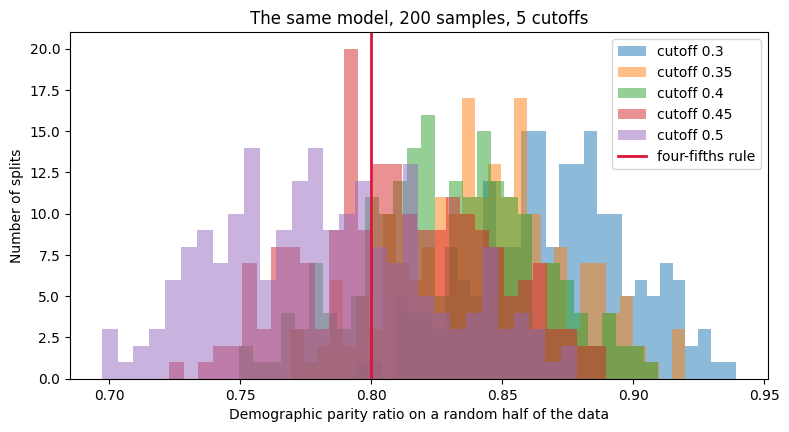

In [20]:
cutoffs = [0.30, 0.35, 0.40, 0.45, 0.50]
S = 200
rows = []
for s in range(S):
    idx = rng.choice(n, n // 2, replace=False)
    ys, ps, As = y.values[idx], p.values[idx], A.values[idx]
    for c in cutoffs:
        yh = (ps >= c).astype(int)
        dpr = demographic_parity_ratio(ys, yh, sensitive_features=As, method='between_groups')
        eod = equalized_odds_difference(ys, yh, sensitive_features=As, method='between_groups')
        rows.append({'split': s, 'cutoff': c, 'DPR': dpr, 'EOD': eod,
                     'passes four-fifths': dpr >= 0.8, 'passes EOD < 0.10': eod <= 0.10})
dh = pd.DataFrame(rows)

pass_rates = dh.groupby('cutoff')[['passes four-fifths', 'passes EOD < 0.10']].mean().round(2)
pass_rates.columns = ['share of splits passing four-fifths', 'share of splits passing EOD < 0.10']
display(pass_rates)

fig, ax = plt.subplots(figsize=(9, 4.5))
for c in cutoffs:
    ax.hist(dh.loc[dh.cutoff == c, 'DPR'], bins=30, alpha=.5, label=f'cutoff {c}')
ax.axvline(0.8, color='crimson', lw=2, label='four-fifths rule')
ax.set_xlabel('Demographic parity ratio on a random half of the data'); ax.set_ylabel('Number of splits')
ax.set_title('The same model, 200 samples, 5 cutoffs'); ax.legend()
plt.show()

Every row of the table is the same model on the same population. Depending on the half of the data you happened to draw and the cutoff you happened to report, the model passes or fails the four-fifths rule, and the two rules do not even agree with each other. A developer who reports one split at one cutoff is not lying; they are choosing.

The lecture's consequences for validation follow directly:

1. Fix the metric, the groups, the cutoff and the test **before** looking at the results, and write them in the validation plan.
2. Report the verdict across resamples, as a distribution or a confidence interval, never as a single number. The permutation test of B2 is the disciplined version of the histogram above.
3. Document the alternatives that were tried and rejected. The "less discriminatory alternative" doctrine (Gillis, Meursault and Ustun, 2024) can require exactly that record.

## Summary

- **Measure** all three criteria; each answers a different question and none of them alone is "fairness". On this model, independence and separation show gaps of a few points, precision is close to equal across groups, and the scores are not calibrated for any group.
- **Test** before you conclude. Bootstrap intervals, permutation p-values and group-by-group Wald tests turn a gap into a verdict with a colour, and they show where the sample is too small to say anything.
- **Treat** with your eyes open. Group-specific cutoffs deliver separation at a cost in performance and in legal exposure. Calibrating by group delivers sufficiency and breaks separation. You choose the criterion; the theorem says you cannot have both.
- **Do not hack.** Pre-register the metric and the test, report distributions, keep the record of alternatives.

What this lab did not do, because the data have no inputs: pre-processing (reweighing, disparate-impact removal, fair representations) and in-processing (constrained estimation, reductions, adversarial debiasing). Both need the model's features and a training loop; see the lecture slides on treatment for the methods and the references.

### Questions to think about

1. The proxy for race in this dataset is itself built from postcodes. How would an error in the proxy change the verdicts in B2? In which direction?
2. B3 optimised balanced accuracy. Rerun it with `objective='accuracy_score'` and explain what happens and why it is not a fair-lending result.
3. In B4, choose the common cutoff to match a *target* PD (say 3%) instead of the original selection rate. Does the conclusion change?
4. Group `a` has the weakest ROC curve. Is that the model's fault, the data's, or neither? What would you ask the model owner for?